In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\My Data Analytics Projects\anime_dataset.csv")

In [4]:
df.head()

,mal_id,title,title_english,Unnamed: 3,type,source,episodes,status,airing,aired_from,...,members,favorites,season,year,studios,producers,licensors,genres,themes,demographics
0,1,Cowboy Bebop,Cowboy Bebop,NaN,TV,Original,26.0,Finished Airing,False,03/04/1998,...,2051751,89485,spring,1998.0,Sunrise,Bandai Visual|Victor Entertainment|Audio Plann...,Funimation,Action|Award Winning|Sci-Fi,Adult Cast|Space,NaN
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,NaN,Movie,Original,1.0,Finished Airing,False,01/09/2001,...,411149,1782,NaN,NaN,Bones,Sunrise|Bandai Visual,Sony Pictures Entertainment|Funimation,Action|Sci-Fi,Adult Cast|Space,NaN
2,6,Trigun,Trigun,NaN,TV,Manga,26.0,Finished Airing,False,01/04/1998,...,832801,17610,spring,1998.0,Madhouse,Victor Entertainment|Arts Pro,Funimation,Action|Adventure|Sci-Fi,Adult Cast,Shounen
3,7,Witch Hunter Robin,Witch Hunter Robin,NaN,TV,Original,26.0,Finished Airing,False,03/07/2002,...,129274,707,summer,2002.0,Sunrise,Bandai Visual|Dentsu|Victor Entertainment,Funimation|Bandai Entertainment,Action|Drama|Mystery|Supernatural,Detective,NaN
4,8,Bouken Ou Beet,Beet the Vandel Buster,NaN,TV,Manga,52.0,Finished Airing,False,30/09/2004,...,16881,18,fall,2004.0,Toei Animation,TV Tokyo|Dentsu,Illumitoon Entertainment,Action|Adventure|Fantasy,NaN,Shounen


In [5]:
df.columns

Index(['mal_id', 'title', 'title_english', 'Unnamed: 3', 'type', 'source',
       'episodes', 'status', 'airing', 'aired_from', 'aired_to', 'duration',
       'rating', 'score', 'scored_by', 'rank', 'popularity', 'members',
       'favorites', 'season', 'year', 'studios', 'producers', 'licensors',
       'genres', 'themes', 'demographics'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30075 entries, 0 to 30074
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   mal_id         30075 non-null  int64  
 1   title          30075 non-null  str    
 2   title_english  13306 non-null  str    
 3   Unnamed: 3     0 non-null      float64
 4   type           30003 non-null  str    
 5   source         30075 non-null  str    
 6   episodes       29236 non-null  float64
 7   status         30075 non-null  str    
 8   airing         30075 non-null  bool   
 9   aired_from     29166 non-null  str    
 10  aired_to       11594 non-null  str    
 11  duration       30075 non-null  str    
 12  rating         29473 non-null  str    
 13  score          19892 non-null  float64
 14  scored_by      19892 non-null  float64
 15  rank           22584 non-null  float64
 16  popularity     30075 non-null  int64  
 17  members        30075 non-null  int64  
 18  favorites      30

In [7]:
df.describe()

,mal_id,Unnamed: 3,episodes,score,scored_by,rank,popularity,members,favorites,year
count,30075.000000,0.0,29236.000000,19892.00000,1.989200e+04,22584.000000,30075.000000,3.007500e+04,30075.000000,6525.000000
mean,35019.558537,NaN,13.958886,6.42559,2.969837e+04,11275.337894,14957.319501,3.901396e+04,429.132801,2010.646130
std,19983.466507,NaN,47.334180,0.89078,1.225328e+05,6508.725236,8634.251988,1.693139e+05,4550.008408,13.294049
min,1.000000,NaN,1.000000,1.89000,1.010000e+02,1.000000,1.000000,0.000000e+00,0.000000,1961.000000
25%,16833.000000,NaN,1.000000,5.80000,3.180000e+02,5636.750000,7483.000000,2.430000e+02,0.000000,2005.000000
50%,38852.000000,NaN,2.000000,6.41000,1.456000e+03,11275.000000,14946.000000,1.088000e+03,1.000000,2014.000000
75%,52131.500000,NaN,13.000000,7.07000,9.676250e+03,16909.250000,22428.000000,9.307500e+03,17.000000,2021.000000
max,64012.000000,NaN,3000.000000,9.27000,3.060289e+06,22548.000000,29935.000000,4.348557e+06,251194.000000,2027.000000


In [8]:
# Checking missing values 

In [9]:
df.isnull().sum().sort_values(ascending=False)

Unnamed: 3       30075
licensors        24877
season           23550
year             23550
demographics     18941
aired_to         18481
title_english    16769
producers        15796
themes           12098
studios          11938
scored_by        10183
score            10183
rank              7491
genres            6394
aired_from         909
episodes           839
rating             602
type                72
mal_id               0
status               0
airing               0
source               0
title                0
favorites            0
members              0
popularity           0
duration             0
dtype: int64

In [10]:
df.drop(columns=['Unnamed: 3'], inplace=True)

In [11]:
df.duplicated(subset=['mal_id', 'title']).sum()

np.int64(139)

In [12]:
duplicates = df[df.duplicated(subset=['mal_id', 'title'], keep=False)]

duplicates[['mal_id', 'title']]

,mal_id,title
25001,56205,Microcosm
25002,56205,Microcosm
25010,56222,Neoki Yashinoki (Aqua Minato Cover)
25011,56222,Neoki Yashinoki (Aqua Minato Cover)
27237,59599,Kensaku to Enjin no Goshigoshi Tearai
...,...,...
30043,63960,Hidan no Aria (Shinsaku Short Anime)
30065,63997,Biblia Koshodou no Jiken Techou
30066,63997,Biblia Koshodou no Jiken Techou
30073,64012,The Ribbon Hero


In [13]:
df = df.drop_duplicates(subset=['mal_id'], keep='first')

In [14]:
df.duplicated(subset=['mal_id', 'title']).sum()

np.int64(0)

In [15]:
df['title_english'] = df['title_english'].fillna(df['title'])

In [16]:
cols = [
    'season',
    'studios',
    'producers',
    'licensors',
    'genres',
    'themes',
    'demographics'
]

df[cols] = df[cols].fillna('NA')

In [17]:
df.head()

,mal_id,title,title_english,type,source,episodes,status,airing,aired_from,aired_to,...,members,favorites,season,year,studios,producers,licensors,genres,themes,demographics
0,1,Cowboy Bebop,Cowboy Bebop,TV,Original,26.0,Finished Airing,False,03/04/1998,24/04/1999,...,2051751,89485,spring,1998.0,Sunrise,Bandai Visual|Victor Entertainment|Audio Plann...,Funimation,Action|Award Winning|Sci-Fi,Adult Cast|Space,NA
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,Movie,Original,1.0,Finished Airing,False,01/09/2001,NaN,...,411149,1782,NA,NaN,Bones,Sunrise|Bandai Visual,Sony Pictures Entertainment|Funimation,Action|Sci-Fi,Adult Cast|Space,NA
2,6,Trigun,Trigun,TV,Manga,26.0,Finished Airing,False,01/04/1998,30/09/1998,...,832801,17610,spring,1998.0,Madhouse,Victor Entertainment|Arts Pro,Funimation,Action|Adventure|Sci-Fi,Adult Cast,Shounen
3,7,Witch Hunter Robin,Witch Hunter Robin,TV,Original,26.0,Finished Airing,False,03/07/2002,25/12/2002,...,129274,707,summer,2002.0,Sunrise,Bandai Visual|Dentsu|Victor Entertainment,Funimation|Bandai Entertainment,Action|Drama|Mystery|Supernatural,Detective,NA
4,8,Bouken Ou Beet,Beet the Vandel Buster,TV,Manga,52.0,Finished Airing,False,30/09/2004,29/09/2005,...,16881,18,fall,2004.0,Toei Animation,TV Tokyo|Dentsu,Illumitoon Entertainment,Action|Adventure|Fantasy,NA,Shounen


In [18]:
df['aired_from'] = pd.to_datetime(df['aired_from'], errors='coerce')

In [19]:
df['year'] = df['year'].fillna(df['aired_from'].dt.year)

In [20]:
df.head()

,mal_id,title,title_english,type,source,episodes,status,airing,aired_from,aired_to,...,members,favorites,season,year,studios,producers,licensors,genres,themes,demographics
0,1,Cowboy Bebop,Cowboy Bebop,TV,Original,26.0,Finished Airing,False,1998-03-04,24/04/1999,...,2051751,89485,spring,1998.0,Sunrise,Bandai Visual|Victor Entertainment|Audio Plann...,Funimation,Action|Award Winning|Sci-Fi,Adult Cast|Space,NA
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,Movie,Original,1.0,Finished Airing,False,2001-01-09,NaN,...,411149,1782,NA,2001.0,Bones,Sunrise|Bandai Visual,Sony Pictures Entertainment|Funimation,Action|Sci-Fi,Adult Cast|Space,NA
2,6,Trigun,Trigun,TV,Manga,26.0,Finished Airing,False,1998-01-04,30/09/1998,...,832801,17610,spring,1998.0,Madhouse,Victor Entertainment|Arts Pro,Funimation,Action|Adventure|Sci-Fi,Adult Cast,Shounen
3,7,Witch Hunter Robin,Witch Hunter Robin,TV,Original,26.0,Finished Airing,False,2002-03-07,25/12/2002,...,129274,707,summer,2002.0,Sunrise,Bandai Visual|Dentsu|Victor Entertainment,Funimation|Bandai Entertainment,Action|Drama|Mystery|Supernatural,Detective,NA
4,8,Bouken Ou Beet,Beet the Vandel Buster,TV,Manga,52.0,Finished Airing,False,NaT,29/09/2005,...,16881,18,fall,2004.0,Toei Animation,TV Tokyo|Dentsu,Illumitoon Entertainment,Action|Adventure|Fantasy,NA,Shounen


In [21]:
df.isnull().sum()

mal_id               0
title                0
title_english        0
type                64
source               0
episodes           746
status               0
airing               0
aired_from       13614
aired_to         18351
duration             0
rating             554
score            10068
scored_by        10068
rank              7387
popularity           0
members              0
favorites            0
season               0
year             12376
studios              0
producers            0
licensors            0
genres               0
themes               0
demographics         0
dtype: int64

In [22]:
def get_season(month):
    if month in [1, 2, 3]:
        return 'Winter'
    elif month in [4, 5, 6]:
        return 'Spring'
    elif month in [7, 8, 9]:
        return 'Summer'
    elif month in [10, 11, 12]:
        return 'Fall'

mask = df['season'] == 'NA'

df.loc[mask, 'season'] = (
    df.loc[mask, 'aired_from']
      .dt.month
      .map(get_season)
)

In [23]:
df.head()

,mal_id,title,title_english,type,source,episodes,status,airing,aired_from,aired_to,...,members,favorites,season,year,studios,producers,licensors,genres,themes,demographics
0,1,Cowboy Bebop,Cowboy Bebop,TV,Original,26.0,Finished Airing,False,1998-03-04,24/04/1999,...,2051751,89485,spring,1998.0,Sunrise,Bandai Visual|Victor Entertainment|Audio Plann...,Funimation,Action|Award Winning|Sci-Fi,Adult Cast|Space,NA
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,Movie,Original,1.0,Finished Airing,False,2001-01-09,NaN,...,411149,1782,Winter,2001.0,Bones,Sunrise|Bandai Visual,Sony Pictures Entertainment|Funimation,Action|Sci-Fi,Adult Cast|Space,NA
2,6,Trigun,Trigun,TV,Manga,26.0,Finished Airing,False,1998-01-04,30/09/1998,...,832801,17610,spring,1998.0,Madhouse,Victor Entertainment|Arts Pro,Funimation,Action|Adventure|Sci-Fi,Adult Cast,Shounen
3,7,Witch Hunter Robin,Witch Hunter Robin,TV,Original,26.0,Finished Airing,False,2002-03-07,25/12/2002,...,129274,707,summer,2002.0,Sunrise,Bandai Visual|Dentsu|Victor Entertainment,Funimation|Bandai Entertainment,Action|Drama|Mystery|Supernatural,Detective,NA
4,8,Bouken Ou Beet,Beet the Vandel Buster,TV,Manga,52.0,Finished Airing,False,NaT,29/09/2005,...,16881,18,fall,2004.0,Toei Animation,TV Tokyo|Dentsu,Illumitoon Entertainment,Action|Adventure|Fantasy,NA,Shounen


In [24]:
#Release Month

In [25]:
df['release_month'] = df['aired_from'].dt.month_name()

In [26]:
#Decade

In [27]:
df['decade'] = (df['year'] // 10) * 10

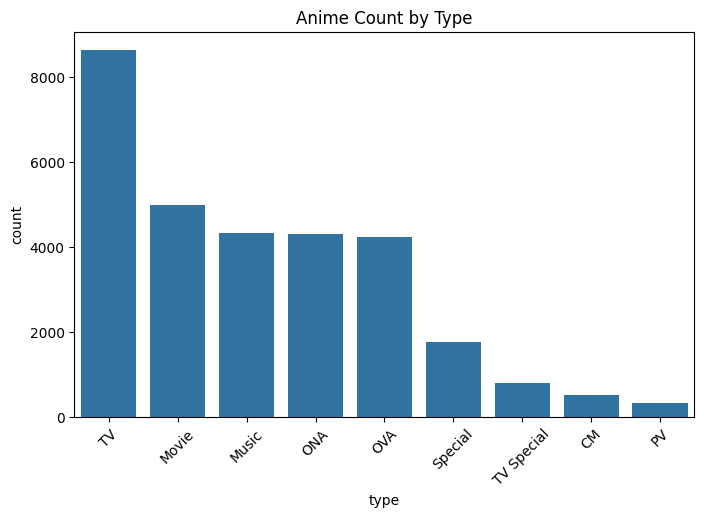

In [28]:
#Anime Type Distribution

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='type', order=df['type'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Anime Count by Type')
plt.show()

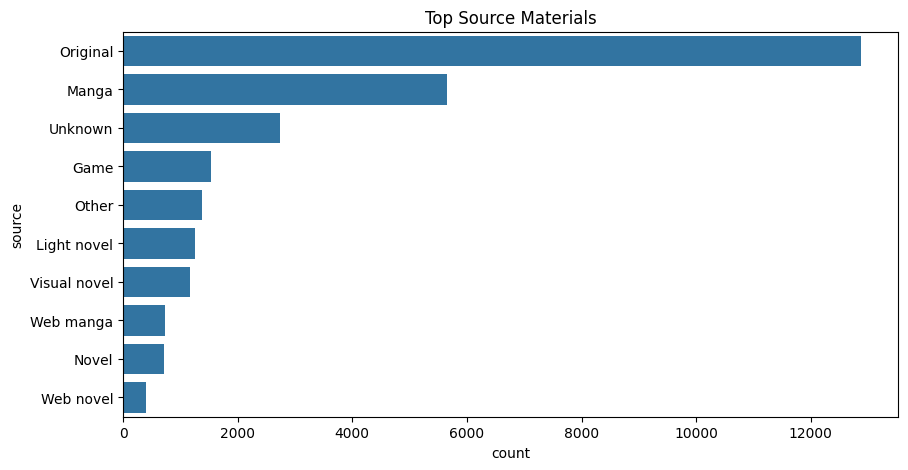

In [29]:
#Source Material Distribution
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    y='source',
    order=df['source'].value_counts().head(10).index
)
plt.title('Top Source Materials')
plt.show()

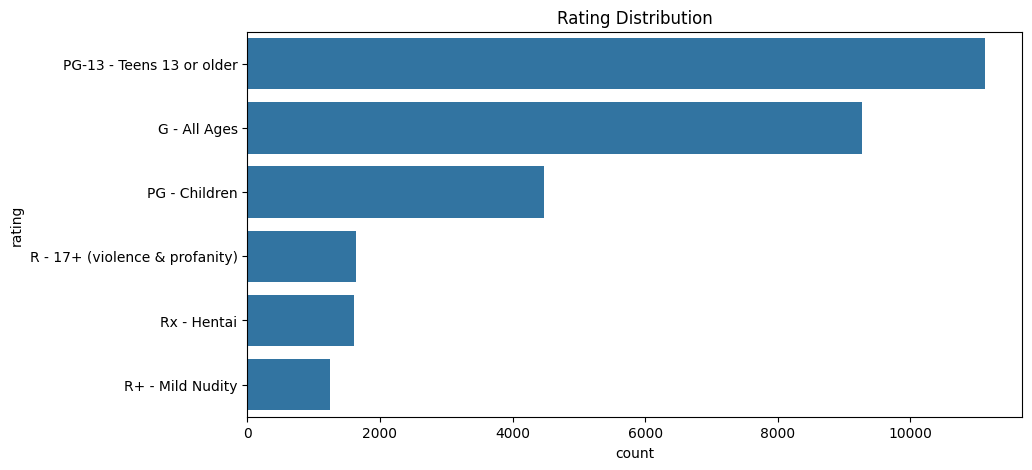

In [30]:
#Rating Distribution

plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    y='rating',
    order=df['rating'].value_counts().index
)
plt.title('Rating Distribution')
plt.show()

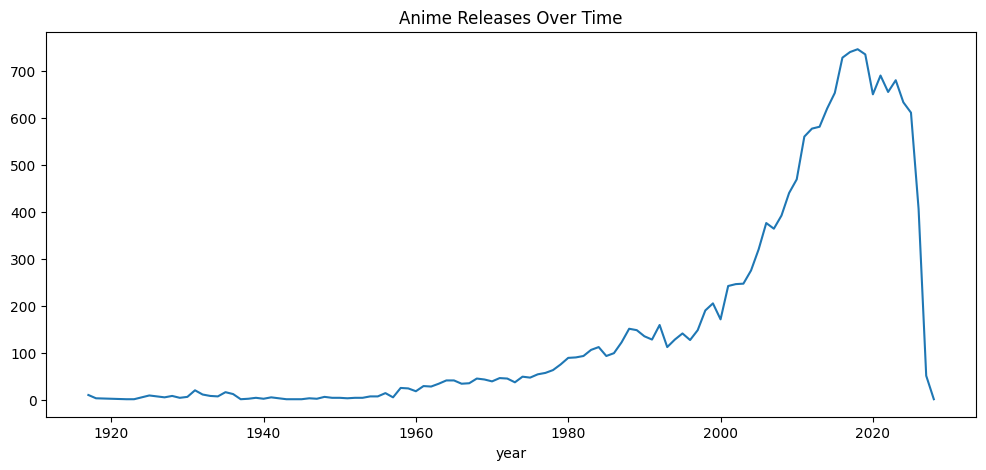

In [31]:
#Anime Release By Years
anime_per_year = (
    df['year']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,5))
anime_per_year.plot()
plt.title('Anime Releases Over Time')
plt.show()

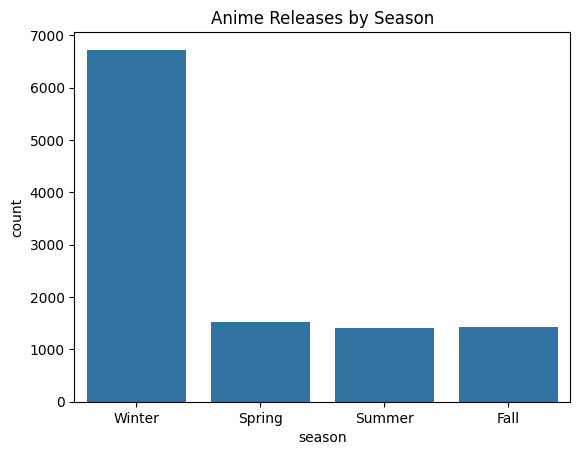

In [32]:
#Anime Release By season
sns.countplot(
    data=df,
    x='season',
    order=['Winter','Spring','Summer','Fall']
)
plt.title('Anime Releases by Season')
plt.show()

In [33]:
# Top 10 Highest rated anime 
top_rated = (
    df[df['scored_by'] > 10000]
    .sort_values('score', ascending=False)
    [['title_english','score']]
    .head(10)
)

top_rated

,title_english,score
23037,Frieren: Beyond Journey's End,9.27
28465,Steel Ball Run: JoJo's Bizarre Adventure,9.15
3959,Fullmetal Alchemist: Brotherhood,9.11
25957,Chainsaw Man – The Movie: Reze Arc,9.08
5662,Steins;Gate,9.07
15489,Gintama: The Very Final,9.05
14838,Attack on Titan Season 3 Part 2,9.05
9871,Gintama Season 4,9.05
6451,Hunter x Hunter,9.03
27514,One Piece Fan Letter,9.02


In [34]:
# Top 10 most popular animes

df.sort_values(
    'members',
    ascending=False
)[['title_english','members']].head(10)

,title_english,members
7423,Attack on Titan,4348557
1393,Death Note,4287273
3959,Fullmetal Alchemist: Brotherhood,3673510
10399,One-Punch Man,3512528
14516,Demon Slayer: Kimetsu no Yaiba,3437705
11125,My Hero Academia,3296918
6591,Sword Art Online,3293547
6451,Hunter x Hunter,3178812
10,Naruto,3109995
8611,Tokyo Ghoul,3049828


In [35]:
#Top studios
df[df['studios'] != 'NA']['studios'].value_counts().head(10)

studios
Toei Animation                    895
Sunrise                           562
J.C.Staff                         418
TMS Entertainment                 376
Shanghai Animation Film Studio    342
Madhouse                          337
Studio Deen                       307
Production I.G                    279
Studio Pierrot                    272
OLM                               265
Name: count, dtype: int64

In [36]:
df.columns

Index(['mal_id', 'title', 'title_english', 'type', 'source', 'episodes',
       'status', 'airing', 'aired_from', 'aired_to', 'duration', 'rating',
       'score', 'scored_by', 'rank', 'popularity', 'members', 'favorites',
       'season', 'year', 'studios', 'producers', 'licensors', 'genres',
       'themes', 'demographics', 'release_month', 'decade'],
      dtype='str')

In [44]:
df.to_csv('anime_data_analysis.csv', index=False)